# TP Module 1 — MLP pour la classification d'images médicales

**Formation avancée en Deep Learning avec PyTorch — Computer Vision & Séries temporelles**

*Bassem Ben Hamed — ENETCOM, Université de Sfax*

---

## Objectifs du TP

Construire, entraîner et analyser un **Perceptron Multi-Couches (MLP)** pour la classification d'images **médicales** (radiographies thoraciques — **PneumoniaMNIST**), en couvrant à la fois la **théorie** et la **mise en œuvre PyTorch** :

1. Comprendre le neurone artificiel et les fonctions d'activation
2. Maîtriser **forward** et **backpropagation** (équations + implémentation)
3. Comparer les **optimiseurs** (SGD, SGD+momentum, Adam)
4. Appliquer la **régularisation** : Dropout, BatchNorm, weight decay
5. Comprendre l'**initialisation des poids** (Xavier, Kaiming)
6. Évaluer un classifieur : accuracy, matrice de confusion, précision/rappel, F1 — en tenant compte du **déséquilibre des classes** (contexte médical)
7. Visualiser et **diagnostiquer** un entraînement (courbes, prédictions, erreurs)

## Pré-requis

- Le TP précédent `01_premiers_pas_pytorch.ipynb`
- `torch`, `torchvision`, `torchmetrics`, `medmnist`, `matplotlib`, `numpy`

```bash
pip install torch torchvision torchmetrics medmnist matplotlib numpy
```

## Partie I — Rappels théoriques

### I.1 Le neurone artificiel

Un **neurone** réalise une combinaison affine de ses entrées suivie d'une non-linéarité :

$$
z = \sum_{i=1}^{n} w_i x_i + b = \mathbf{w}^\top \mathbf{x} + b,
\qquad
a = \varphi(z)
$$

- $\mathbf{x} \in \mathbb{R}^n$ : vecteur d'entrée
- $\mathbf{w} \in \mathbb{R}^n$, $b \in \mathbb{R}$ : **paramètres apprenables** (poids, biais)
- $\varphi : \mathbb{R} \to \mathbb{R}$ : fonction d'activation non linéaire
- $z$ : *pré-activation* ou *logit local*
- $a$ : *activation*, sortie du neurone

**Pourquoi une non-linéarité ?** Sans $\varphi$, l'empilement de couches reste linéaire :
$\mathbf{W}_2 (\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1) + \mathbf{b}_2 = \mathbf{W}' \mathbf{x} + \mathbf{b}'$.
Tout réseau profond linéaire est équivalent à une seule couche linéaire — il ne peut séparer que des classes linéairement séparables.

### I.2 Architecture d'un MLP à $L$ couches

Un MLP est une suite de transformations affines + activations. Pour un réseau à $L$ couches cachées plus une couche de sortie :

$$
\mathbf{h}^{(0)} = \mathbf{x},
\qquad
\mathbf{z}^{(\ell)} = \mathbf{W}^{(\ell)} \mathbf{h}^{(\ell-1)} + \mathbf{b}^{(\ell)},
\qquad
\mathbf{h}^{(\ell)} = \varphi^{(\ell)}(\mathbf{z}^{(\ell)})
\quad \text{pour } \ell = 1, \dots, L
$$

- $\mathbf{W}^{(\ell)} \in \mathbb{R}^{n_\ell \times n_{\ell-1}}$ : matrice des poids de la couche $\ell$
- $\mathbf{b}^{(\ell)} \in \mathbb{R}^{n_\ell}$ : biais de la couche $\ell$
- $n_\ell$ : nombre de neurones de la couche $\ell$

**Nombre de paramètres** d'une couche dense `nn.Linear(in_features=n_in, out_features=n_out)` :
$\#\text{params} = n_\text{in} \cdot n_\text{out} + n_\text{out}$
(poids + biais).

Pour PneumoniaMNIST (28×28 = 784 pixels, 2 classes), un MLP `[784 → 256 → 128 → 2]` a :
$$
(784 \cdot 256 + 256) + (256 \cdot 128 + 128) + (128 \cdot 2 + 2) = 234\,114 \text{ paramètres}.
$$

### I.3 Fonctions d'activation

| Activation | Formule | Dérivée | Plage | Usage typique |
|------------|---------|---------|-------|---------------|
| **Sigmoid** | $\sigma(z) = \dfrac{1}{1+e^{-z}}$ | $\sigma(z)(1-\sigma(z))$ | $(0, 1)$ | sortie binaire, déconseillée en couche cachée |
| **Tanh** | $\tanh(z) = \dfrac{e^z - e^{-z}}{e^z + e^{-z}}$ | $1 - \tanh^2(z)$ | $(-1, 1)$ | RNN, centrée en 0 |
| **ReLU** | $\max(0, z)$ | $\mathbf{1}_{z>0}$ | $[0, +\infty)$ | par défaut en CNN/MLP |
| **LeakyReLU** | $\max(\alpha z, z)$ (ex. $\alpha = 0.01$) | $\alpha$ si $z<0$, 1 sinon | $\mathbb{R}$ | corrige *dying ReLU* |
| **GELU** | $z \cdot \Phi(z)$ | (différentiable partout) | $\mathbb{R}$ | Transformers, ViT |
| **Softmax** | $\dfrac{e^{z_k}}{\sum_j e^{z_j}}$ | (cf. CrossEntropy) | $(0, 1)$, somme = 1 | sortie multi-classes |

**Le problème du *vanishing gradient* (sigmoid/tanh)** : leur dérivée maximale vaut 0.25 (sigmoid) ou 1 (tanh). Avec la règle de la chaîne sur $L$ couches, les gradients sont multipliés $L$ fois : ils tendent rapidement vers 0 en profondeur, gelant l'apprentissage des premières couches. **ReLU** n'a pas ce défaut car sa dérivée vaut 1 sur la partie positive.

### I.4 Forward, loss, softmax + cross-entropy

Pour la classification à $K$ classes, la dernière couche produit un **vecteur de logits** $\mathbf{z} \in \mathbb{R}^K$. La probabilité prédite pour la classe $k$ est :

$$
\hat{p}_k = \text{softmax}(\mathbf{z})_k = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}.
$$

La **Cross-Entropy** entre la vraie étiquette $y$ (one-hot) et $\hat{\mathbf{p}}$ est :

$$
\mathcal{L}_\text{CE}(\mathbf{z}, y) = -\log \hat{p}_y = -z_y + \log \sum_{j=1}^{K} e^{z_j}.
$$

Sur un batch de $N$ échantillons :
$$
\mathcal{L} = \frac{1}{N} \sum_{i=1}^{N} \mathcal{L}_\text{CE}(\mathbf{z}^{(i)}, y^{(i)}).
$$

**Astuce numérique** : `nn.CrossEntropyLoss` en PyTorch combine `log_softmax` + `NLLLoss` (LogSumExp stable). **Ne pas** appliquer `softmax` manuellement avant — passer les logits bruts.

**Gradient au niveau des logits** (résultat remarquable et élégant) :
$$
\frac{\partial \mathcal{L}_\text{CE}}{\partial z_k} = \hat{p}_k - \mathbf{1}_{k=y}.
$$
C'est ce qui rend le couple softmax+CE numériquement et conceptuellement propre.

### I.5 Backpropagation — règle de la chaîne

On note $\boldsymbol{\delta}^{(\ell)} = \dfrac{\partial \mathcal{L}}{\partial \mathbf{z}^{(\ell)}}$ le *signal d'erreur* à la couche $\ell$. Les équations de rétropropagation sont :

$$
\boxed{\;
\boldsymbol{\delta}^{(L)} = \hat{\mathbf{p}} - \mathbf{y}_\text{onehot}
\quad\text{(sortie softmax+CE)}
\;}
$$

$$
\boxed{\;
\boldsymbol{\delta}^{(\ell)} = \left( \mathbf{W}^{(\ell+1)\top} \boldsymbol{\delta}^{(\ell+1)} \right) \odot \varphi'\!\left(\mathbf{z}^{(\ell)}\right)
\quad\text{pour } \ell = L-1, \dots, 1
\;}
$$

Les gradients par rapport aux paramètres en découlent immédiatement :

$$
\frac{\partial \mathcal{L}}{\partial \mathbf{W}^{(\ell)}} = \boldsymbol{\delta}^{(\ell)} \, \mathbf{h}^{(\ell-1)\top},
\qquad
\frac{\partial \mathcal{L}}{\partial \mathbf{b}^{(\ell)}} = \boldsymbol{\delta}^{(\ell)}.
$$

**En PyTorch**, tout cela est calculé automatiquement par `autograd` lors de l'appel `loss.backward()` — vous n'avez à coder que la **forward**.

### I.6 Optimiseurs

Mise à jour générique : $\boldsymbol{\theta}_{t+1} = \boldsymbol{\theta}_t - \eta \cdot \text{update}(\mathbf{g}_t)$ où $\mathbf{g}_t = \nabla_{\boldsymbol{\theta}} \mathcal{L}(\boldsymbol{\theta}_t)$ est le gradient courant et $\eta$ le *learning rate*.

**SGD (Stochastic Gradient Descent)** :
$$
\boldsymbol{\theta}_{t+1} = \boldsymbol{\theta}_t - \eta \, \mathbf{g}_t.
$$

**SGD + Momentum** (Polyak, accélère dans les vallées étroites, atténue les oscillations) :
$$
\mathbf{v}_{t} = \mu \, \mathbf{v}_{t-1} + \mathbf{g}_t,
\qquad
\boldsymbol{\theta}_{t+1} = \boldsymbol{\theta}_t - \eta \, \mathbf{v}_t,
\qquad \mu \in [0, 1) \;\text{(typique : 0.9)}.
$$

**Adam** (Adaptive Moment Estimation) — combine moment de l'ordre 1 et 2 du gradient :
$$
\mathbf{m}_t = \beta_1 \mathbf{m}_{t-1} + (1-\beta_1) \mathbf{g}_t,
\qquad
\mathbf{v}_t = \beta_2 \mathbf{v}_{t-1} + (1-\beta_2) \mathbf{g}_t^{\odot 2}
$$

Correction de biais (les moments démarrent à 0) :
$$
\hat{\mathbf{m}}_t = \frac{\mathbf{m}_t}{1 - \beta_1^t},
\qquad
\hat{\mathbf{v}}_t = \frac{\mathbf{v}_t}{1 - \beta_2^t}
$$

Mise à jour :
$$
\boldsymbol{\theta}_{t+1} = \boldsymbol{\theta}_t - \eta \cdot \frac{\hat{\mathbf{m}}_t}{\sqrt{\hat{\mathbf{v}}_t} + \varepsilon},
\qquad \beta_1=0.9,\; \beta_2=0.999,\; \varepsilon=10^{-8}.
$$

#### Exemple numérique — un pas d'Adam

Soit $g_1 = 0.5$ (premier pas, $t=1$), $\eta = 10^{-3}$, $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\varepsilon = 10^{-8}$, état initial $m_0 = v_0 = 0$.

$\begin{aligned}
m_1 &= 0.9 \cdot 0 + 0.1 \cdot 0.5 = 0.05 \\
v_1 &= 0.999 \cdot 0 + 0.001 \cdot 0.25 = 2.5 \cdot 10^{-4} \\
\hat{m}_1 &= 0.05 / (1 - 0.9) = 0.5 \\
\hat{v}_1 &= 2.5{\cdot}10^{-4} / (1 - 0.999) = 0.25 \\
\Delta\theta &= -10^{-3} \cdot \frac{0.5}{\sqrt{0.25} + 10^{-8}} \approx -10^{-3}.
\end{aligned}$

Au **premier** pas, Adam fait toujours un pas de taille $\approx \eta$ — c'est par construction (la correction de biais ramène les moments au niveau du gradient brut).

### I.7 Régularisation

**Weight Decay** ($L^2$) : ajoute $\frac{\lambda}{2} \|\boldsymbol{\theta}\|^2$ à la loss. Équivalent à $\boldsymbol{\theta} \gets (1 - \eta\lambda)\boldsymbol{\theta} - \eta\mathbf{g}$. En PyTorch : `torch.optim.Adam(..., weight_decay=1e-4)`.

**Dropout** : à l'entraînement, chaque neurone est désactivé indépendamment avec probabilité $p$. Les activations restantes sont multipliées par $1/(1-p)$ pour conserver l'espérance. À l'inférence (`model.eval()`), Dropout est désactivé. En PyTorch : `nn.Dropout(p=0.3)`.

**Batch Normalization** — normalise chaque feature sur le batch courant, puis applique une transformation affine apprenable $\gamma, \beta$ :
$$
\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \varepsilon}},
\qquad
y_i = \gamma \hat{x}_i + \beta.
$$
Stabilise et accélère l'entraînement, autorise des $\eta$ plus grands. En PyTorch : `nn.BatchNorm1d(num_features)` (avant l'activation).

**Early Stopping** : on arrête quand la val loss ne s'améliore plus pendant *patience* epochs.

### I.8 Initialisation des poids

Le choix de l'initialisation conditionne la variance des activations en profondeur. Une mauvaise init fait diverger (variance explosive) ou geler (variance nulle) le réseau.

**Xavier / Glorot** (adapté à `tanh`, `sigmoid`) :
$$
W_{ij} \sim \mathcal{N}\!\left(0,\; \frac{2}{n_\text{in} + n_\text{out}}\right).
$$

**Kaiming / He** (adapté à ReLU et variantes) :
$$
W_{ij} \sim \mathcal{N}\!\left(0,\; \frac{2}{n_\text{in}}\right).
$$

PyTorch :
```python
torch.nn.init.kaiming_normal_(layer.weight, nonlinearity="relu")
torch.nn.init.xavier_uniform_(layer.weight)
torch.nn.init.zeros_(layer.bias)
```

Par défaut, `nn.Linear` utilise une initialisation uniforme de type Kaiming — souvent suffisante.

## Partie II — Mise en œuvre PyTorch

### II.1 Imports et configuration

In [1]:
import os
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from medmnist import PneumoniaMNIST, INFO

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {device}")
if device.type == "cuda":
    print(f"GPU      : {torch.cuda.get_device_name(0)}")

DATA_DIR = Path("./data")
CKPT_DIR = Path("./checkpoints")
DATA_DIR.mkdir(exist_ok=True); CKPT_DIR.mkdir(exist_ok=True)

PyTorch  : 2.10.0
Device   : cpu


### II.2 Dataset PneumoniaMNIST

**PneumoniaMNIST** fait partie de la collection [MedMNIST](https://medmnist.com/) — des jeux de données médicaux au format *MNIST-like* (images 28×28). Il s'agit de **radiographies thoraciques pédiatriques** rééchantillonnées en 28×28 niveaux de gris, à classer en **2 classes** : *Normal* vs *Pneumonie*.

- **Splits fournis** : 4 708 (train) / 524 (val) / 624 (test) — on utilise directement les splits officiels de MedMNIST (pas de `random_split` maison).
- **Déséquilibre** : le train compte ~1 214 cas *Normal* contre ~3 494 cas *Pneumonie* (≈ 26 % / 74 %). Important à garder en tête pour l'évaluation : l'accuracy seule est trompeuse, d'où le suivi de la **précision/rappel/F1 par classe**.

**Pipeline des transforms** :
- `ToTensor()` — convertit PIL → tenseur `(C, H, W)` float dans $[0, 1]$
- `Normalize(mean, std)` — standardise : $x' = (x - \mu)/\sigma$. Pour PneumoniaMNIST, $\mu \approx 0.5719$, $\sigma \approx 0.1684$ (statistiques calculées sur le train).

**Détail MedMNIST** : chaque étiquette est renvoyée sous forme de tableau `np.array([classe])`. On applique un `target_transform` pour la convertir en entier scalaire, attendu par `nn.CrossEntropyLoss`.

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5719,), (0.1684,)),   # statistiques PneumoniaMNIST (train)
])

# MedMNIST renvoie chaque label sous forme np.array([classe]) -> on extrait l'entier
target_transform = lambda t: int(t[0])

# Splits officiels MedMNIST (pas de random_split : val déjà fourni)
common = dict(transform=transform, target_transform=target_transform,
              download=True, root=DATA_DIR, size=28)
train_set = PneumoniaMNIST(split="train", **common)
val_set   = PneumoniaMNIST(split="val",   **common)
test_set  = PneumoniaMNIST(split="test",  **common)

# Étiquettes lisibles, dans l'ordre des indices de classe (cf. INFO["pneumoniamnist"]["label"])
CLASSES = ["Normal", "Pneumonie"]

print(f"Train : {len(train_set):>5} | Val : {len(val_set):>5} | Test : {len(test_set):>5}")

x0, y0 = train_set[0]
print(f"Forme d'une image : {x0.shape}  | dtype : {x0.dtype}")
print(f"min = {x0.min():.3f}, max = {x0.max():.3f}, moyenne = {x0.mean():.3f}")
print(f"Label : {y0} ({CLASSES[y0]})")

Train :  4708 | Val :   524 | Test :   624
Forme d'une image : torch.Size([1, 28, 28])  | dtype : torch.float32
min = -3.396, max = 1.844, moyenne = 0.191
Label : 1 (Pneumonie)


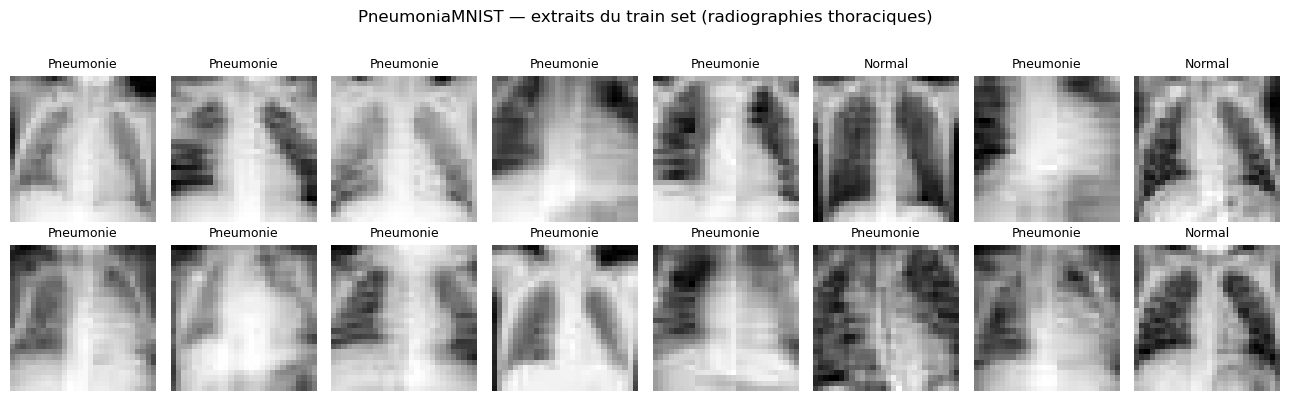

In [3]:
# Visualisation d'une grille d'échantillons
fig, axes = plt.subplots(2, 8, figsize=(13, 4))
for ax, (img, label) in zip(axes.flat, [train_set[i] for i in range(16)]):
    ax.imshow(img.squeeze().numpy(), cmap="gray")
    ax.set_title(CLASSES[label], fontsize=9)
    ax.axis("off")
plt.suptitle("PneumoniaMNIST — extraits du train set (radiographies thoraciques)", y=1.02)
plt.tight_layout(); plt.show()

In [4]:
BATCH = 128
NUM_WORKERS = 0   # mettre 2-4 si CPU multi-coeurs
PIN = device.type == "cuda"

train_loader = DataLoader(train_set, batch_size=BATCH, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=PIN)
val_loader   = DataLoader(val_set,   batch_size=BATCH, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN)
test_loader  = DataLoader(test_set,  batch_size=BATCH, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN)

# Inspection d'un batch
x_batch, y_batch = next(iter(train_loader))
print(f"Batch images : {x_batch.shape}  (N, C, H, W)")
print(f"Batch labels : {y_batch.shape}  | dtype : {y_batch.dtype}")

Batch images : torch.Size([128, 1, 28, 28])  (N, C, H, W)
Batch labels : torch.Size([128])  | dtype : torch.int64


### II.3 Définition du MLP

On définit une classe générique `MLP` qui prend en paramètres :
- `in_dim` : 784 pour PneumoniaMNIST (28×28 *aplaties*)
- `hidden_dims` : liste des tailles de couches cachées
- `num_classes` : 2 (*Normal* / *Pneumonie*)
- `dropout`, `use_bn` : options de régularisation

**Important** : la première opération est `nn.Flatten()` (de `(N, 1, 28, 28)` vers `(N, 784)`). Sans cela, `nn.Linear` reçoit la mauvaise dimension.

In [5]:
class MLP(nn.Module):
    def __init__(self, in_dim=784, hidden_dims=(256, 128), num_classes=2,
                 dropout=0.0, use_bn=False, activation="relu"):
        super().__init__()
        act_layer = {
            "relu":  nn.ReLU,
            "tanh":  nn.Tanh,
            "gelu":  nn.GELU,
            "lrelu": lambda: nn.LeakyReLU(0.01),
        }[activation]

        layers = [nn.Flatten()]
        prev = in_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_bn:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, num_classes))     # logits — pas de softmax ici
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

    @staticmethod
    def count_params(model):
        return sum(p.numel() for p in model.parameters() if p.requires_grad)

model = MLP(hidden_dims=(256, 128), dropout=0.2, use_bn=True).to(device)
print(model)
print(f"\nNombre de paramètres apprenables : {MLP.count_params(model):,}")

MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.2, inplace=False)
    (5): Linear(in_features=256, out_features=128, bias=True)
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=128, out_features=2, bias=True)
  )
)

Nombre de paramètres apprenables : 234,882


### II.4 Vérification de la forward sur un batch

Avant tout entraînement, on vérifie :
1. Le modèle prend bien la forme attendue.
2. La sortie a la bonne forme `(N, num_classes)`.
3. Les **logits** ne sont **pas** déjà des probabilités (ils peuvent être négatifs).

In [6]:
model.eval()
with torch.no_grad():
    logits = model(x_batch.to(device))
print(f"Entrée : {x_batch.shape}  ->  Sortie (logits) : {logits.shape}")
print(f"Logits exemple 0 : {logits[0].cpu().numpy().round(2)}")
print(f"Probas softmax   : {F.softmax(logits[0], dim=0).cpu().numpy().round(3)}")
print(f"Prédiction       : classe {logits[0].argmax().item()} ({CLASSES[logits[0].argmax().item()]})")

Entrée : torch.Size([128, 1, 28, 28])  ->  Sortie (logits) : torch.Size([128, 2])
Logits exemple 0 : [0.   0.13]
Probas softmax   : [0.468 0.532]
Prédiction       : classe 1 (Pneumonie)


### II.5 Boucle d'entraînement avec métriques

On factorise en deux fonctions, mais cette fois on **suit l'accuracy** en plus de la loss.

In [7]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, total_correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss   = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss    += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total         += x.size(0)
    return total_loss / total, total_correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss   = criterion(logits, y)
        total_loss    += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total         += x.size(0)
    return total_loss / total, total_correct / total

def fit(model, train_loader, val_loader, criterion, optimizer, device,
        epochs=10, scheduler=None, log_every=1):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = 0.0
    best_state   = None
    t0 = time.time()
    for epoch in range(1, epochs + 1):
        tl, ta = train_one_epoch(model, train_loader, criterion, optimizer, device)
        vl, va = evaluate(model, val_loader, criterion, device)
        if scheduler is not None:
            scheduler.step()
        history["train_loss"].append(tl); history["train_acc"].append(ta)
        history["val_loss"].append(vl);   history["val_acc"].append(va)
        if va > best_val_acc:
            best_val_acc = va
            best_state   = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        if epoch % log_every == 0 or epoch == 1:
            print(f"epoch {epoch:>2}/{epochs} | "
                  f"train: loss={tl:.4f} acc={ta:.4f} | "
                  f"val: loss={vl:.4f} acc={va:.4f}")
    print(f"\nDurée totale : {time.time()-t0:.1f}s | best val acc : {best_val_acc:.4f}")
    return history, best_state, best_val_acc

### II.6 Entraînement du modèle baseline

**Configuration baseline** :
- Architecture : `[784 → 256 → 128 → 2]` avec ReLU + BatchNorm + Dropout(0.2)
- Loss : `CrossEntropyLoss` (combine `log_softmax` + `NLLLoss`)
- Optimiseur : Adam, `lr=1e-3`, `weight_decay=1e-4`
- 10 epochs, batch 128

In [8]:
torch.manual_seed(SEED)
model     = MLP(hidden_dims=(256, 128), dropout=0.2, use_bn=True, activation="relu").to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

history, best_state, best_val_acc = fit(
    model, train_loader, val_loader, criterion, optimizer, device,
    epochs=10,
)

# Recharger le meilleur état avant de tester
model.load_state_dict(best_state)
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"\nTest : loss = {test_loss:.4f} | accuracy = {test_acc:.4f}")

epoch  1/10 | train: loss=0.2411 acc=0.9074 | val: loss=0.1228 acc=0.9599
epoch  2/10 | train: loss=0.1142 acc=0.9596 | val: loss=0.1161 acc=0.9618
epoch  3/10 | train: loss=0.0988 acc=0.9675 | val: loss=0.1022 acc=0.9656
epoch  4/10 | train: loss=0.0807 acc=0.9709 | val: loss=0.0935 acc=0.9637
epoch  5/10 | train: loss=0.0729 acc=0.9747 | val: loss=0.1092 acc=0.9618
epoch  6/10 | train: loss=0.0711 acc=0.9739 | val: loss=0.0809 acc=0.9656
epoch  7/10 | train: loss=0.0613 acc=0.9792 | val: loss=0.0764 acc=0.9656
epoch  8/10 | train: loss=0.0592 acc=0.9768 | val: loss=0.1009 acc=0.9656
epoch  9/10 | train: loss=0.0543 acc=0.9807 | val: loss=0.0929 acc=0.9580
epoch 10/10 | train: loss=0.0594 acc=0.9760 | val: loss=0.0994 acc=0.9580

Durée totale : 2.1s | best val acc : 0.9656

Test : loss = 0.4741 | accuracy = 0.8333


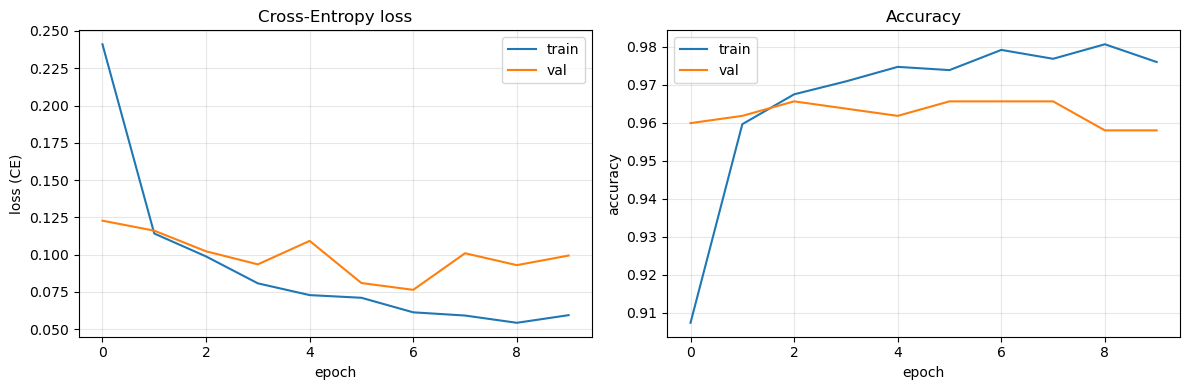

In [9]:
# Courbes d'apprentissage
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"],   label="val")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss (CE)"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title("Cross-Entropy loss")

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"],   label="val")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title("Accuracy")
plt.tight_layout(); plt.show()

### II.7 Diagnostic : matrice de confusion et erreurs

Forme prédictions : (624,), vrais : (624,), probas : (624, 2)


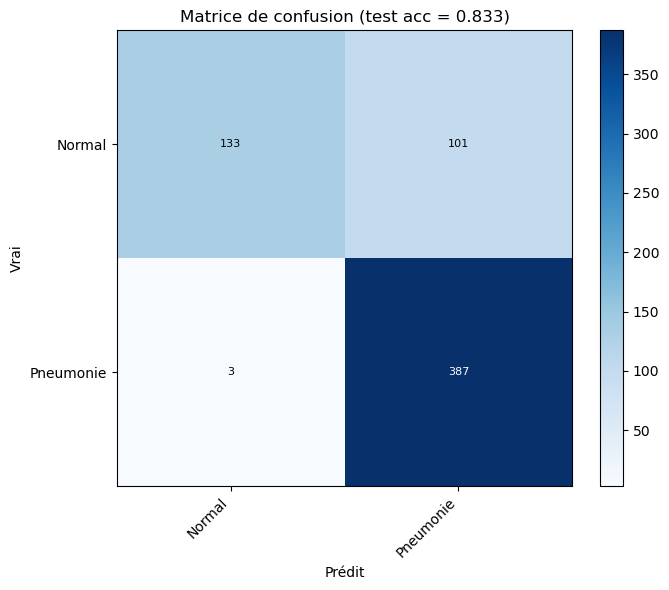

In [10]:
@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    y_true, y_pred, y_probs = [], [], []
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        probs  = F.softmax(logits, dim=1)
        y_true.append(y.numpy())
        y_pred.append(logits.argmax(dim=1).cpu().numpy())
        y_probs.append(probs.cpu().numpy())
    return np.concatenate(y_true), np.concatenate(y_pred), np.concatenate(y_probs)

y_true, y_pred, y_probs = get_predictions(model, test_loader, device)
print(f"Forme prédictions : {y_pred.shape}, vrais : {y_true.shape}, probas : {y_probs.shape}")

# Matrice de confusion (à la main, sans sklearn)
K = len(CLASSES)
cm = np.zeros((K, K), dtype=int)
for t, p in zip(y_true, y_pred):
    cm[t, p] += 1

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(K)); ax.set_yticks(range(K))
ax.set_xticklabels(CLASSES, rotation=45, ha="right")
ax.set_yticklabels(CLASSES)
ax.set_xlabel("Prédit"); ax.set_ylabel("Vrai")
ax.set_title(f"Matrice de confusion (test acc = {test_acc:.3f})")
for i in range(K):
    for j in range(K):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

In [11]:
# Accuracy et F1 par classe
per_class_acc = cm.diagonal() / cm.sum(axis=1)

# F1 = 2 * (precision * recall) / (precision + recall)
precision = cm.diagonal() / cm.sum(axis=0).clip(min=1)
recall    = cm.diagonal() / cm.sum(axis=1).clip(min=1)
f1        = 2 * precision * recall / (precision + recall).clip(min=1e-12)

print(f"{'Classe':<12} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7}")
print("-" * 44)
for c, a, p, r, fs in zip(CLASSES, per_class_acc, precision, recall, f1):
    print(f"{c:<12} {a:>7.3f} {p:>7.3f} {r:>7.3f} {fs:>7.3f}")
print("-" * 44)
print(f"{'Macro avg':<12} {per_class_acc.mean():>7.3f} "
      f"{precision.mean():>7.3f} {recall.mean():>7.3f} {f1.mean():>7.3f}")

Classe           Acc    Prec     Rec      F1
--------------------------------------------
Normal         0.568   0.978   0.568   0.719
Pneumonie      0.992   0.793   0.992   0.882
--------------------------------------------
Macro avg      0.780   0.885   0.780   0.800


Échantillons mal classés sur le test : 104/624 (16.7%)


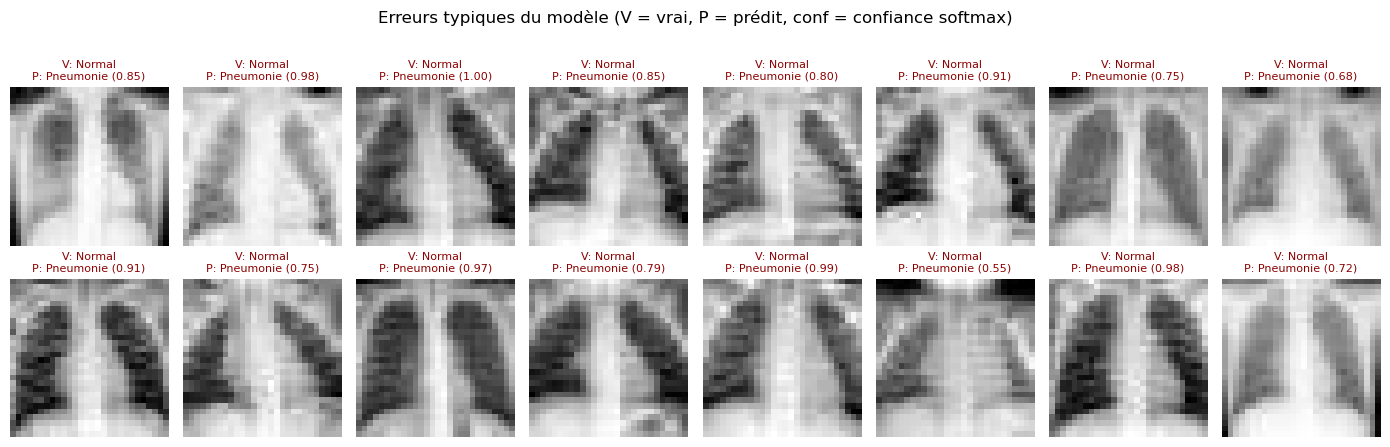

In [12]:
# Visualisation des échantillons MAL classés (avec la probabilité de la prédiction erronée)
wrong_idx = np.where(y_true != y_pred)[0]
print(f"Échantillons mal classés sur le test : {len(wrong_idx)}/{len(y_true)} ({len(wrong_idx)/len(y_true)*100:.1f}%)")

# Récupère un échantillon d'images mal classées (au plus 16)
rng = np.random.default_rng(SEED)
n_show = min(16, len(wrong_idx))
sel = rng.choice(wrong_idx, size=n_show, replace=False)

fig, axes = plt.subplots(2, 8, figsize=(14, 4.5))
for ax in axes.flat:
    ax.axis("off")
for ax, idx in zip(axes.flat, sel):
    img, _ = test_set[idx]
    ax.imshow(img.squeeze().numpy(), cmap="gray")
    pred_conf = y_probs[idx, y_pred[idx]]
    ax.set_title(f"V: {CLASSES[y_true[idx]]}\nP: {CLASSES[y_pred[idx]]} ({pred_conf:.2f})",
                 fontsize=8, color="darkred")
plt.suptitle("Erreurs typiques du modèle (V = vrai, P = prédit, conf = confiance softmax)", y=1.02)
plt.tight_layout(); plt.show()

### II.8 Étude comparative — Optimiseurs

On entraîne **trois modèles identiques** avec trois optimiseurs : SGD, SGD+momentum, Adam.

*Pour gagner du temps, on limite à 5 epochs et à un dataset réduit. L'objectif est qualitatif : voir l'effet du momentum et d'Adam.*

In [13]:
def run_experiment(opt_name, model_kwargs=None, opt_kwargs=None, epochs=5, lr=1e-2):
    torch.manual_seed(SEED)
    model = MLP(**(model_kwargs or {})).to(device)
    criterion = nn.CrossEntropyLoss()
    if opt_name == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, **(opt_kwargs or {}))
    elif opt_name == "sgd_mom":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif opt_name == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr/10)   # Adam préfère lr plus petit
    history, *_ = fit(model, train_loader, val_loader, criterion, optimizer, device,
                     epochs=epochs, log_every=epochs)   # seulement la dernière epoch
    return history

MODEL_KW = dict(hidden_dims=(256, 128), dropout=0.0, use_bn=False, activation="relu")
EPOCHS_CMP = 5

print("--- SGD nu ---")
h_sgd      = run_experiment("sgd",     MODEL_KW, epochs=EPOCHS_CMP, lr=1e-2)
print("\n--- SGD + momentum 0.9 ---")
h_sgd_mom  = run_experiment("sgd_mom", MODEL_KW, epochs=EPOCHS_CMP, lr=1e-2)
print("\n--- Adam ---")
h_adam     = run_experiment("adam",    MODEL_KW, epochs=EPOCHS_CMP, lr=1e-2)

--- SGD nu ---
epoch  1/5 | train: loss=0.5973 acc=0.6799 | val: loss=0.4955 acc=0.7538
epoch  5/5 | train: loss=0.1756 acc=0.9397 | val: loss=0.1649 acc=0.9504

Durée totale : 0.8s | best val acc : 0.9523

--- SGD + momentum 0.9 ---
epoch  1/5 | train: loss=0.3824 acc=0.8061 | val: loss=0.1508 acc=0.9447
epoch  5/5 | train: loss=0.0971 acc=0.9645 | val: loss=0.1114 acc=0.9561

Durée totale : 0.8s | best val acc : 0.9561

--- Adam ---
epoch  1/5 | train: loss=0.2229 acc=0.9012 | val: loss=0.1330 acc=0.9523
epoch  5/5 | train: loss=0.0848 acc=0.9701 | val: loss=0.1143 acc=0.9542

Durée totale : 0.9s | best val acc : 0.9618


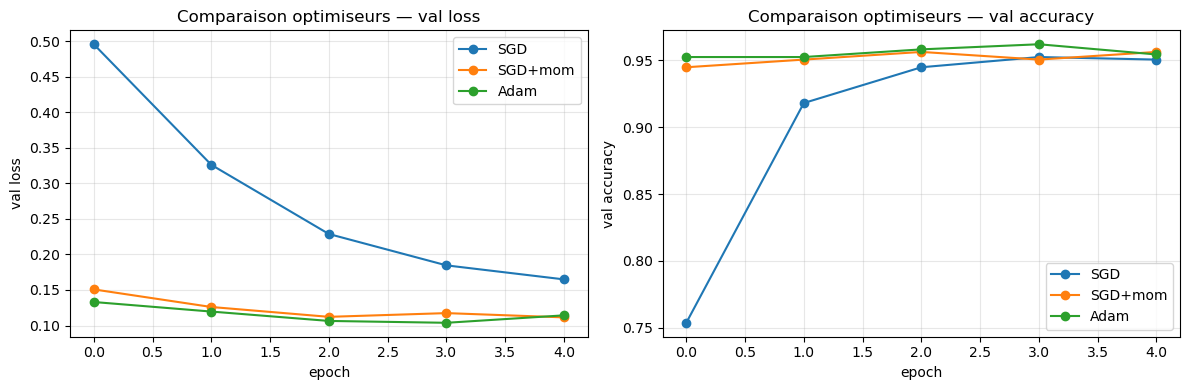

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, h in [("SGD", h_sgd), ("SGD+mom", h_sgd_mom), ("Adam", h_adam)]:
    axes[0].plot(h["val_loss"], marker="o", label=label)
    axes[1].plot(h["val_acc"],  marker="o", label=label)
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("val loss"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title("Comparaison optimiseurs — val loss")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("val accuracy"); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title("Comparaison optimiseurs — val accuracy")
plt.tight_layout(); plt.show()

**Observations attendues :**
- **SGD nu** : convergence lente, peut nécessiter beaucoup d'epochs.
- **SGD + momentum** : nette amélioration, le momentum lisse la trajectoire.
- **Adam** : converge le plus vite en début d'entraînement, souvent meilleur résultat en peu d'epochs. *Mais* sur de longs entraînements, SGD+momentum bien tuné égale ou dépasse Adam en généralisation.

### II.9 Étude comparative — Régularisation

On compare un modèle **sans** régularisation à des modèles avec **Dropout** et avec **BatchNorm**.

In [15]:
def quick_train(model_kwargs, epochs=8, lr=1e-3):
    torch.manual_seed(SEED)
    model = MLP(**model_kwargs).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history, *_ = fit(model, train_loader, val_loader, criterion, optimizer, device,
                     epochs=epochs, log_every=epochs)
    return history

configs = {
    "baseline":  dict(hidden_dims=(512, 256), dropout=0.0, use_bn=False),
    "dropout":   dict(hidden_dims=(512, 256), dropout=0.3, use_bn=False),
    "batchnorm": dict(hidden_dims=(512, 256), dropout=0.0, use_bn=True),
    "both":      dict(hidden_dims=(512, 256), dropout=0.3, use_bn=True),
}

results = {}
for name, cfg in configs.items():
    print(f"--- {name} ---")
    results[name] = quick_train(cfg, epochs=8)
    print()

--- baseline ---
epoch  1/8 | train: loss=0.2028 acc=0.9040 | val: loss=0.1471 acc=0.9408
epoch  8/8 | train: loss=0.0620 acc=0.9764 | val: loss=0.1104 acc=0.9580

Durée totale : 1.7s | best val acc : 0.9599

--- dropout ---
epoch  1/8 | train: loss=0.2123 acc=0.9044 | val: loss=0.1278 acc=0.9447
epoch  8/8 | train: loss=0.0770 acc=0.9711 | val: loss=0.1228 acc=0.9561

Durée totale : 1.8s | best val acc : 0.9599

--- batchnorm ---
epoch  1/8 | train: loss=0.1918 acc=0.9203 | val: loss=0.1126 acc=0.9561
epoch  8/8 | train: loss=0.0358 acc=0.9879 | val: loss=0.0951 acc=0.9656

Durée totale : 2.0s | best val acc : 0.9695

--- both ---
epoch  1/8 | train: loss=0.2104 acc=0.9108 | val: loss=0.1191 acc=0.9561
epoch  8/8 | train: loss=0.0611 acc=0.9764 | val: loss=0.1037 acc=0.9618

Durée totale : 1.9s | best val acc : 0.9656



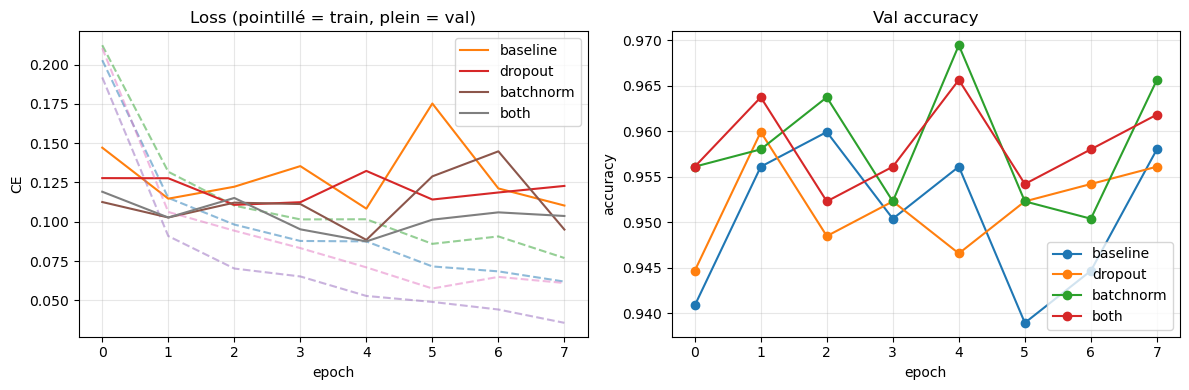

Meilleure val accuracy par config :
    baseline : 0.9599
     dropout : 0.9599
   batchnorm : 0.9695
        both : 0.9656


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, h in results.items():
    axes[0].plot(h["train_loss"], linestyle="--", alpha=0.5)
    axes[0].plot(h["val_loss"],   label=name)
    axes[1].plot(h["val_acc"],    label=name, marker="o")
axes[0].set_title("Loss (pointillé = train, plein = val)"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("CE")
axes[1].set_title("Val accuracy"); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy")
plt.tight_layout(); plt.show()

print("Meilleure val accuracy par config :")
for name, h in results.items():
    print(f"  {name:>10} : {max(h['val_acc']):.4f}")

**Lecture des courbes :**
- **Écart train-val** important sur baseline → *overfitting* (d'autant plus marqué que le dataset est petit, ~4,7k images).
- Dropout et/ou BatchNorm réduisent cet écart.
- Sur PneumoniaMNIST en MLP, on atteint typiquement ~80-85 % d'accuracy — mais vu le **déséquilibre** (74 % de pneumonie), regardez surtout le **rappel sur la classe *Normal*** et le **F1 macro**, pas seulement l'accuracy. Pour aller plus loin, un CNN (Module 1.2) exploite la structure spatiale des radiographies.

### II.10 Inspection des gradients — détecter vanishing/exploding

Un bon diagnostic consiste à observer la **norme des gradients** par couche. Sur un MLP profond avec **sigmoid**, on doit voir les gradients devenir minuscules dans les premières couches.

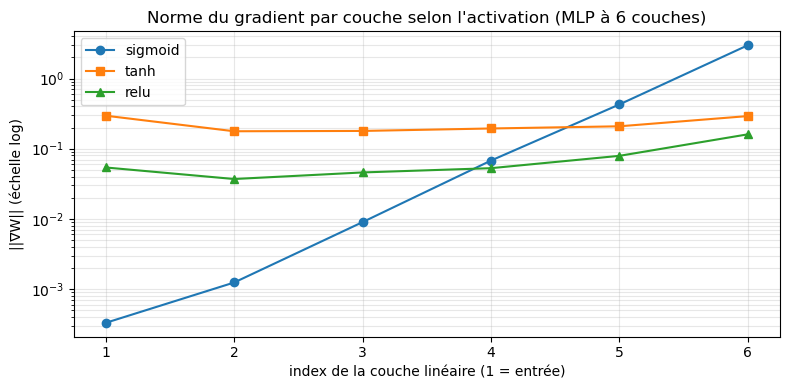

On observe que sigmoid s'écroule rapidement (vanishing gradient) tandis que ReLU reste stable.


In [17]:
def measure_grad_norms(activation, hidden_dims=(256, 256, 256, 256, 256)):
    """Entraîne 1 step et renvoie la norme L2 du gradient de chaque couche linéaire."""
    torch.manual_seed(SEED)
    model = MLP(hidden_dims=hidden_dims, activation=activation, dropout=0.0, use_bn=False).to(device)
    criterion = nn.CrossEntropyLoss()

    x, y = next(iter(train_loader))
    x, y = x.to(device), y.to(device)

    logits = model(x)
    loss   = criterion(logits, y)
    loss.backward()

    grads = []
    for name, p in model.named_parameters():
        if name.endswith(".weight") and p.grad is not None and p.dim() == 2:
            grads.append(p.grad.norm().item())
    return grads

g_relu    = measure_grad_norms("relu")
g_tanh    = measure_grad_norms("tanh")
# Sigmoid n'est pas dans la classe MLP — on l'ajoute spécifiquement

class MLPSigmoid(nn.Module):
    def __init__(self, hidden=(256,256,256,256,256), num_classes=2):
        super().__init__()
        layers = [nn.Flatten()]
        prev = 784
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.Sigmoid()]
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

torch.manual_seed(SEED)
m_sig = MLPSigmoid().to(device)
x, y = next(iter(train_loader)); x, y = x.to(device), y.to(device)
loss = nn.CrossEntropyLoss()(m_sig(x), y); loss.backward()
g_sigmoid = [p.grad.norm().item() for n, p in m_sig.named_parameters()
             if n.endswith(".weight") and p.dim() == 2]

plt.figure(figsize=(8, 4))
layers = list(range(1, len(g_relu) + 1))
plt.semilogy(layers, g_sigmoid, marker="o", label="sigmoid")
plt.semilogy(layers, g_tanh,    marker="s", label="tanh")
plt.semilogy(layers, g_relu,    marker="^", label="relu")
plt.xlabel("index de la couche linéaire (1 = entrée)")
plt.ylabel("||∇W|| (échelle log)")
plt.title("Norme du gradient par couche selon l'activation (MLP à 6 couches)")
plt.legend(); plt.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

print("On observe que sigmoid s'écroule rapidement (vanishing gradient) tandis que ReLU reste stable.")

### II.11 Sauvegarde du meilleur modèle

In [18]:
ckpt_path = CKPT_DIR / "mlp_pneumonia_best.pt"
torch.save({
    "model_state_dict":  best_state,
    "architecture":      dict(hidden_dims=(256, 128), num_classes=2, dropout=0.2, use_bn=True, activation="relu"),
    "normalize_mean":    0.5719,
    "normalize_std":     0.1684,
    "classes":           CLASSES,
    "best_val_acc":      best_val_acc,
    "test_acc":          test_acc,
}, ckpt_path)
print(f"Modèle sauvegardé : {ckpt_path}")
print(f"Taille fichier   : {ckpt_path.stat().st_size / 1024:.1f} KB")

Modèle sauvegardé : checkpoints/mlp_pneumonia_best.pt
Taille fichier   : 926.5 KB


## Partie III — Exercices d'application

### Exercice 1 — Architecture
Variez la profondeur et la largeur du MLP. Tracez **test accuracy (et F1 macro) vs nombre de paramètres** pour les configurations suivantes :
- `[128]`, `[256]`, `[512]`, `[1024]`
- `[256, 128]`, `[512, 256, 128]`, `[1024, 512, 256, 128]`

Quelle est la configuration la plus efficace en nombre de paramètres ?

### Exercice 2 — Learning rate scheduler
Ajoutez un `torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)`. Comparez la courbe à un entraînement à lr constant.

### Exercice 3 — Gérer le déséquilibre des classes
PneumoniaMNIST est **déséquilibré** (~26 % *Normal* / 74 % *Pneumonie*). Comparez :
- CrossEntropy standard
- CrossEntropy pondérée : `nn.CrossEntropyLoss(weight=...)` avec `weight = 1/freq_classe` (calculée sur le train).

Observez l'effet sur le **rappel de la classe minoritaire (*Normal*)** et sur le F1 macro — pas seulement sur l'accuracy globale.

### Exercice 4 — Initialisation manuelle
Modifiez `MLP` pour permettre l'initialisation Kaiming sur ReLU et Xavier sur Tanh via :
```python
def _init_weights(self):
    for m in self.modules():
        if isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            nn.init.zeros_(m.bias)
```
Comparez vitesse de convergence vs init par défaut PyTorch.

### Exercice 5 — Inférence pas à pas
Chargez le checkpoint `mlp_pneumonia_best.pt`, reconstruisez l'architecture à partir des métadonnées sauvegardées, et écrivez une fonction `predict(image_path)` qui charge une radiographie, applique la transform, et renvoie `(classe, confiance)`.

### Exercice 6 — Pourquoi un MLP plafonne sur les images ?
Calculez le nombre de paramètres d'un MLP `[784 → 1024 → 512 → 2]`. Comparez à un CNN simple `Conv(1→32, 3×3) → Pool → Conv(32→64, 3×3) → Pool → Linear(...)`.

Argumentez en quelques lignes pourquoi le CNN est *intrinsèquement* mieux adapté aux images médicales (invariance par translation, partage de paramètres, hiérarchie de features — détection de motifs locaux d'opacité pulmonaire).

---

## Synthèse — concepts et API

| Concept | API PyTorch |
|---------|-------------|
| Aplatissement | `nn.Flatten()` |
| Couche dense | `nn.Linear(in, out)` |
| Activations | `nn.ReLU`, `nn.Tanh`, `nn.GELU`, `nn.LeakyReLU` |
| Loss multi-classes | `nn.CrossEntropyLoss()` (combine `log_softmax` + `NLLLoss`) |
| Loss pondérée (déséquilibre) | `nn.CrossEntropyLoss(weight=...)` |
| Softmax / probas | `torch.softmax`, `F.softmax` |
| Régularisation | `nn.Dropout(p)`, `nn.BatchNorm1d`, `weight_decay` dans l'optimiseur |
| Optimiseurs | `torch.optim.SGD(momentum=...)`, `torch.optim.Adam` |
| Scheduler | `torch.optim.lr_scheduler.{StepLR, CosineAnnealingLR, OneCycleLR}` |
| Initialisation | `nn.init.kaiming_normal_`, `nn.init.xavier_uniform_` |
| Dataset image médicale | `medmnist.PneumoniaMNIST(split=..., download=True)` |
| Transforms | `transforms.Compose([ToTensor(), Normalize(mean, std)])` |
| Mode | `model.train()` / `model.eval()` |
| Sauvegarde | `torch.save(state_dict)` / `model.load_state_dict(...)` |

---

**Prochain TP** : `03_cnn_images.ipynb` — Convolutions, ResNet, EfficientNet et **CAM** sur images.